In [2]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
from scipy.io import loadmat
from scipy.stats import spearmanrho
from scipy import stats
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, compatible_TimeSeries_check, print_wise, get_lagplot, get_centroid
# from useful_stuff.general_utils.RSA import  dRSA
# from useful_stuff.general_utils.II import  dRSA, dynInformationImbalance
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from project_specific_utils.dataloader import load_concat_regressout_meg
from analyses.subsampling_lagged_comparisons import save_lagged_comparisons
from useful_stuff.general_utils.plots import truncate_colormap
from useful_stuff.general_utils.utils import spearman, softmax


In [20]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    neu_fs = 100
    gaze_fs = 50
    sq_side = 384
    sensors_group = 'occ'
    model_name = "dino_v3_l"
    pkg = "hf"
    len_or_lag = 600
    pseudotrials_n = 100
    n_model_components = 1000
    pooling = "all"
    PCs_to_regress_out = 50
    iterations_n = 1000
    repetition = 1
    signal_metric = "cosine_cnt"
    model_metric = "cosine_cnt"
    regress_out_gaze = 'PCR' # or None or pointwise
    PCs_to_regress_out = 50
    max_lag = 300
    analysis_type = "RSA"
    tick_step = 100
    min_peak_percent=.01
    negative_lim = 1
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, pkg=cfg.pkg)
mod_fs = config["movie_fs"]
model_len = [round(i*cfg.neu_fs/config["movie_fs"]) for i in config["model_len"]]
lags = np.arange(-cfg.max_lag, cfg.max_lag + 1)

# SUBJECTS AVERAGE

In [4]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from useful_stuff.general_utils.plots import truncate_colormap
from useful_stuff.general_utils.utils import get_lagplot
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
 
# --- choose colormap ---
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, len(layers)))
peaks = []
centroids = []
ticks = np.arange(-cfg.max_lag, cfg.max_lag + 1, cfg.tick_step)
ticks_labels = np.round(ticks / cfg.neu_fs, 2)
ticks += cfg.max_lag
all_peaks = []
all_centroids = []
rhos = {"0": [], "1": []}
rs = {"0": [], "1": []}
lagplots = {"0": [], "1": []}
for i_rep in [0, 1]:
    print("rep", i_rep)
    for i_sub in config["subjects"][:10]:
        curr_peaks = []
        curr_centroids = []
        curr_lagplots = []
        for idx, l in enumerate(layers[:]):
            full_model_name = f"{cfg.model_name}_{l}"
            sub_counter = 0
            lagplot_sum = np.zeros(cfg.max_lag*2 +1)
            try:
                res_path = save_lagged_comparisons(paths, cfg.analysis_type, i_sub, cfg.sensors_group, i_rep, full_model_name, cfg.iterations_n, cfg.len_or_lag, cfg.neu_fs, signal_metric=cfg.signal_metric, model_metric=cfg.model_metric, pseudotrials_n=cfg.pseudotrials_n, sq_side=cfg.sq_side, regress_out_gaze=cfg.regress_out_gaze)
                res = loadmat(res_path)["RSA"]    
                lagplot = get_lagplot(res, cfg.max_lag)
                curr_lagplots.append(lagplot)
                sub_counter +=1
            except FileNotFoundError:
                print_wise(f"sub={i_sub} layer={l} not found")
                continue
            peak_lag = (np.argmax(lagplot) - cfg.max_lag) / cfg.neu_fs  # convert to seconds
            curr_peaks.append([idx, peak_lag])
            if np.sum(lagplot < 0) < cfg.negative_lim*len(lagplot):
                centroid_lag = get_centroid(lagplot, cfg.max_lag, cfg.neu_fs, min_peak_percent=cfg.min_peak_percent)
            else:
                centroid_lag = np.nan
            
            if not np.isnan(centroid_lag):
                curr_centroids.append([idx, centroid_lag])
        lagplots[str(i_rep)].append(np.stack(curr_lagplots, axis=0))
        
        if len(curr_centroids)>3:
            curr_centroids = np.stack(curr_centroids)
            curr_peaks = np.stack(curr_peaks)
            
            rho = spearmanrho(curr_centroids[:,1], curr_centroids[:,0])
            print(rho)
            r = np.corrcoef(curr_centroids[:,1], curr_centroids[:,0])[0,1]
            rhos[str(i_rep)].append(rho.statistic)
            rs[str(i_rep)].append(r)
        else:
            rhos[str(i_rep)].append(np.nan)
            rs[str(i_rep)].append(np.nan)


rep 0
SignificanceResult(statistic=np.float64(0.4408695652173913), pvalue=np.float64(0.031055354027520507))
SignificanceResult(statistic=np.float64(0.8895652173913043), pvalue=np.float64(6.110896315326472e-09))
SignificanceResult(statistic=np.float64(-0.17012987012987013), pvalue=np.float64(0.4609431837520657))
SignificanceResult(statistic=np.float64(0.9252173913043478), pvalue=np.float64(9.945790694086272e-11))
SignificanceResult(statistic=np.float64(0.7147826086956521), pvalue=np.float64(8.687380114323498e-05))
SignificanceResult(statistic=np.float64(0.8), pvalue=np.float64(2.706129943926746e-06))
SignificanceResult(statistic=np.float64(-0.09584980237154153), pvalue=np.float64(0.6635269596839091))
SignificanceResult(statistic=np.float64(0.2139130434782609), pvalue=np.float64(0.3155271306915457))
SignificanceResult(statistic=np.float64(-0.5104347826086957), pvalue=np.float64(0.010817218599752912))
SignificanceResult(statistic=np.float64(0.9147826086956522), pvalue=np.float64(3.9823245

In [5]:
centroids

[]

In [6]:
rs = {k: np.tanh(rs[k]) for k in rs.keys()}
rhos = {k: np.tanh(rhos[k]) for k in rhos.keys()}


In [7]:

for i_rep in [0,1]:
    values = rhos[str(i_rep)]
    t_stat, p_val = stats.ttest_1samp(values, 0.0, nan_policy="omit")
    print(f"t = {t_stat:.4f}, p = {p_val:.4g},", f"n = {len(values)}")

t = 2.3945, p = 0.04026, n = 10
t = 1.3000, p = 0.2298, n = 10


In [8]:
r0 = np.asarray(rhos["0"], dtype=float)
r1 = np.asarray(rhos["1"], dtype=float)

n = min(len(r0), len(r1))
t_stat, p_val = stats.ttest_rel(r0[:n], r1[:n], nan_policy="omit")

print(f"paired t-test: t = {t_stat:.4f}, p = {p_val:.4g}, n = {n}")

paired t-test: t = 1.0413, p = 0.3282, n = 10


In [9]:
lagplots["0"][0].shape


(24, 601)

In [10]:
maxes = {"0":[], "1": []}
for i_rep in [0, 1]:
    curr_maxes = []
    for i_sub in lagplots[str(i_rep)]:
        curr_maxes.append(np.max(i_sub, axis=1))
    maxes[str(i_rep)] = np.stack(curr_maxes, axis=1)

In [11]:
maxes = {"0":[], "1": []}
for i_rep in [0, 1]:
    curr_maxes = []
    for i_sub in lagplots[str(i_rep)]:
        curr_maxes.append(np.max(i_sub, axis=1))
    maxes[str(i_rep)] = np.stack(curr_maxes, axis=1)

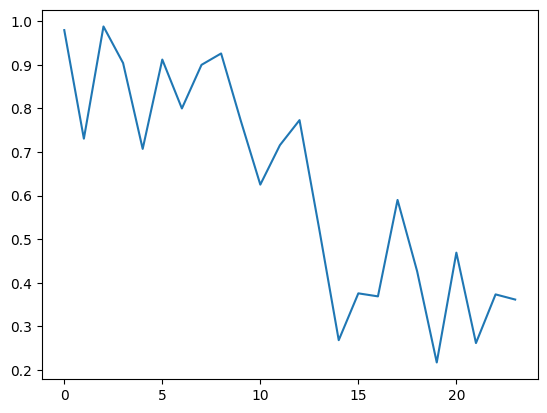

In [15]:
pvals = []
for i_layer in range(len(layers)):
    t_stat, p_val = stats.ttest_1samp(maxes["0"][i_layer, :] - maxes["1"][i_layer, :], 0, nan_policy="omit")
    pvals.append(p_val)
plt.plot(pvals)

In [21]:
sing_sub_centroids = {"0":[], "1": []}
for i_rep in [0, 1]:
    curr_sing_sub_centroids = []
    for lagplot in lagplots[str(i_rep)]:
        curr_layers = []
        for i_layer in range(lagplot.shape[0]):
            lp = lagplot[i_layer, :]
            if np.sum(lp < 0) < cfg.negative_lim*len(lp):
                centroid_lag = get_centroid(lp, cfg.max_lag, cfg.neu_fs, min_peak_percent=cfg.min_peak_percent)
            else:
                centroid_lag = np.nan
            curr_layers.append(centroid_lag)
        curr_sing_sub_centroids.append(np.stack(curr_layers))
    sing_sub_centroids[str(i_rep)] =np.stack(curr_sing_sub_centroids, axis=1)

In [22]:
print(sing_sub_centroids["0"][1, :])
print(sing_sub_centroids["1"][1, :])


[0.29227922 0.07076077 1.19783166 0.48556468 0.01688313 0.20554059
 0.37869896 0.80036055 1.14785931 0.207134  ]
[-0.00128274  0.42286632  0.26711192  0.26460483  0.46796866  0.04131291
  0.10445871  0.56262672  0.86106122  0.25191784]


layer.0.mlp.down_proj 0.7198217875935146
layer.1.mlp.down_proj 0.23108938804870863
layer.2.mlp.down_proj 0.45132329466261334
layer.3.mlp.down_proj 0.8935232815833601
layer.4.mlp.down_proj 0.3134977664993107
layer.5.mlp.down_proj 0.7576771770231753
layer.6.mlp.down_proj 0.6968198259468924
layer.7.mlp.down_proj 0.7105715000715922
layer.8.mlp.down_proj 0.07801699082825295
layer.9.mlp.down_proj 0.4083727143052037
layer.10.mlp.down_proj 0.1206796522340161
layer.11.mlp.down_proj 0.15569695081936655
layer.12.mlp.down_proj 0.10307049371762207
layer.13.mlp.down_proj 0.043876596256912655
layer.14.mlp.down_proj 0.09034561683331435
layer.15.mlp.down_proj 0.054470153482346774
layer.16.mlp.down_proj 0.2542913892706259
layer.17.mlp.down_proj 0.14441199758825138
layer.18.mlp.down_proj 0.18404189285477815
layer.19.mlp.down_proj 0.06808087629417223
layer.20.mlp.down_proj 0.10538884197259595
layer.21.mlp.down_proj 0.2501269042903769
layer.22.mlp.down_proj 0.14501471092886198
layer.23.mlp.down_proj 0.0942

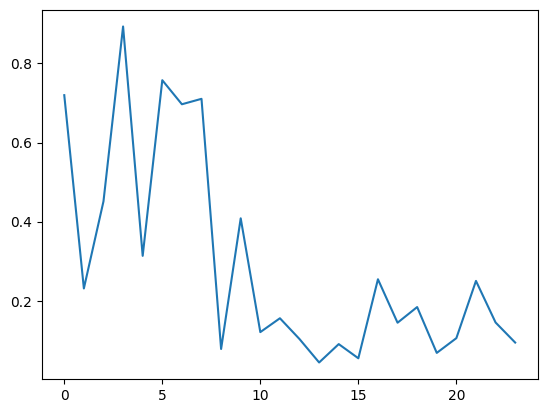

In [24]:
pvals = []
for i in range(len(layers)):
    t, pval =stats.ttest_1samp(sing_sub_centroids["0"][i, :] - sing_sub_centroids["1"][i, :], 0, nan_policy="omit")
    pvals.append(pval)
    print(layers[i], pval)
plt.plot(pvals)
    

In [25]:
avg_lagplots= [np.mean(lagplots[str(i_rep)], axis=0) for i_rep in [0, 1]]

In [28]:
individual_softmaxes = {"0":[], "1":[]}
temp = 0.001
for i_rep in [0,1]:
    for i_sub in lagplots[str(i_rep)]:
        s = []
        for t in range(i_sub.shape[1]):
            s.append(softmax(i_sub[:,t], T=temp)@np.arange(len(layers))/len(layers))
        individual_softmaxes[str(i_rep)].append(np.stack(s))
individual_softmaxes = {k: np.stack(individual_softmaxes[k], axis=0) for k in individual_softmaxes.keys()}

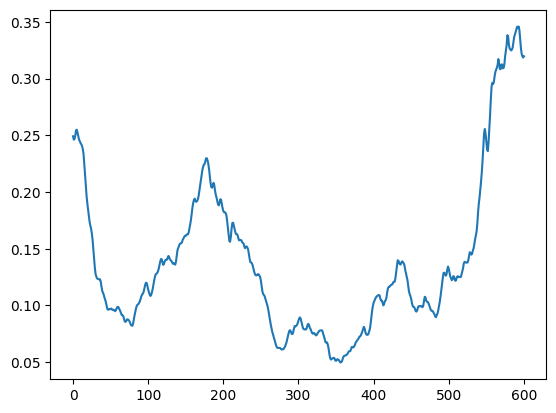

In [29]:
pvals = []
for t in range(2*cfg.max_lag+1):
    t, pval =stats.ttest_1samp(individual_softmaxes["0"][:,t] - individual_softmaxes["1"][:,t], 0)
    pvals.append(pval)
plt.plot(pvals)
    

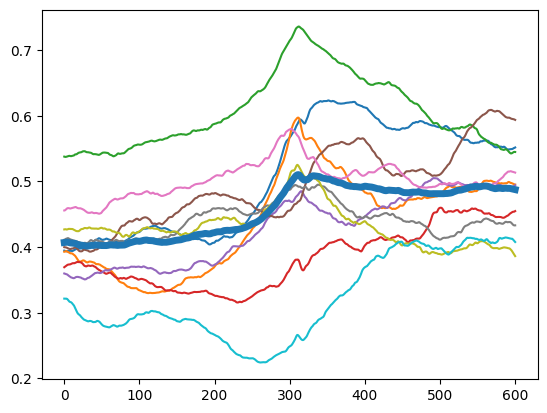

In [32]:
plt.plot(individual_softmaxes["0"].T)
plt.plot(np.mean(individual_softmaxes["0"], axis=0), linewidth=5)

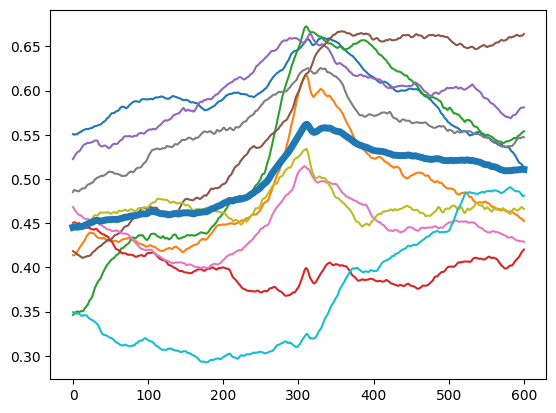

In [35]:
plt.plot(individual_softmaxes["1"].T)
plt.plot(np.mean(individual_softmaxes["1"], axis=0), linewidth=5)

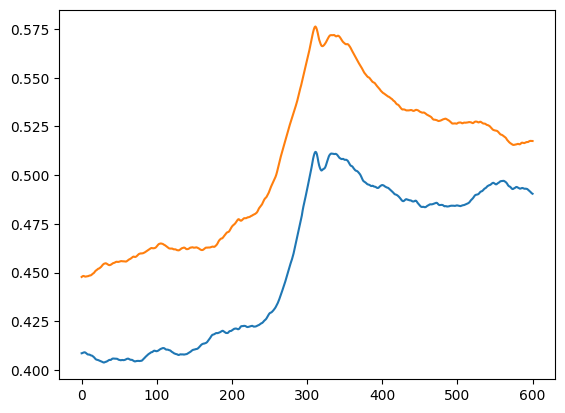

In [ ]:

temp = 0.001
softmaxes = []
for avg in avg_lagplots:
    s = []
    for t in range(avg.shape[1]):
        s.append(softmax(avg[:,t], T=temp)@np.arange(len(layers))/len(layers))
    s = np.stack(s)
    softmaxes.append(s)
    plt.plot(s)

In [82]:
import scipy
scipy.stats.ttest_1samp(softmaxes[0] -softmaxes[1], 0)

TtestResult(statistic=np.float64(-103.6124971127334), pvalue=np.float64(0.0), df=np.int64(600))